Import

In [1]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

Config

In [45]:
DATA_DIR = Path("/workspace/Dataset_train_uniform_final")

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4 #The number of CPU thread 

NUM_CLASSES = 2
CLASS_NAMES = ["Non_Uniform", "Uniform"]

EPOCHS_VIT = 10
EPOCHS_MOBILENET = 5
EPOCHS_KD = 5

LR_VIT = 1e-3
LR_MOBILENET = 1e-4
LR_KD = 1e-4

WEIGHT_DECAY = 0.05

KD_TEMPERATURE = 4.0
KD_ALPHA = 0.5

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory / 1024**3,
            2
        ),
        "GB"
    )

print("=" * 60)

DEVICE: cuda
GPU: NVIDIA GeForce RTX 3090
GPU Memory: 23.57 GB


Seed

In [3]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

Check dataset

In [4]:
train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "val"
test_dir = DATA_DIR / "test"


for directory in [train_dir, val_dir, test_dir]:

    print(
        f"{directory}:",
        "OK" if directory.exists() else "NOT FOUND"
    )

/workspace/Dataset_train_uniform_final/train: OK
/workspace/Dataset_train_uniform_final/val: OK
/workspace/Dataset_train_uniform_final/test: OK


Transform

In [5]:
train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.6, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.4
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Load dataset

In [6]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=eval_transform
)


print("Classes:", train_dataset.classes)

print()
print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

Classes: ['Non_Uniform', 'Uniform']

Train: 8193
Val:   509
Test:  213


Check class distribution

In [7]:
from collections import Counter


def show_distribution(dataset, name):

    counter = Counter(dataset.targets)

    print(f"\n{name}")

    for idx, class_name in enumerate(dataset.classes):

        count = counter[idx]
        percentage = count / len(dataset) * 100

        print(
            f"{class_name:15s}: "
            f"{count:5d} "
            f"({percentage:.2f}%)"
        )


show_distribution(train_dataset, "TRAIN")
show_distribution(val_dataset, "VALIDATION")
show_distribution(test_dataset, "TEST")


TRAIN
Non_Uniform    :  3575 (43.63%)
Uniform        :  4618 (56.37%)

VALIDATION
Non_Uniform    :   213 (41.85%)
Uniform        :   296 (58.15%)

TEST
Non_Uniform    :    91 (42.72%)
Uniform        :   122 (57.28%)


DataLoader

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Test 1 batch

In [9]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

print()
print("Expected:")
print(f"[batch_size, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([1, 0, 1, 1, 1, 1, 1, 0, 1, 0])

Expected:
[batch_size, 3, 224, 224]


Training and evaluation function

In [10]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [11]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Generic Training Loop

In [52]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    learning_rate,
    save_path,
    model_name
):

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = torch.optim.AdamW([
        {
            "params": vit.head.parameters(),
            "lr": 1e-4
        },
        {
            "params": vit.blocks[-1:].parameters(),
            "lr": 1e-6
        }
    ], weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_val_loss = float('inf')

    history = []

    print()
    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    for epoch in range(epochs):

        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step()

        epoch_time = time.time() - start_time

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"| "
            f"Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| "
            f"Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| "
            f"Time: {epoch_time:.1f}s"
        )

        # Save best model
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                model.state_dict(),
                save_path
            )

            print(
                f"  -> Saved best model "
                f"(val_loss={val_loss:.4f})"
            )


    print()
    print(
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )

    return pd.DataFrame(history)

Plot Training

In [13]:
def plot_history(history, title):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )

    # Loss
    axes[0].plot(
        history["epoch"],
        history["train_loss"],
        label="Train"
    )

    axes[0].plot(
        history["epoch"],
        history["val_loss"],
        label="Validation"
    )

    axes[0].set_title(
        f"{title} - Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()


    # Accuracy
    axes[1].plot(
        history["epoch"],
        history["train_acc"],
        label="Train"
    )

    axes[1].plot(
        history["epoch"],
        history["val_acc"],
        label="Validation"
    )

    axes[1].set_title(
        f"{title} - Accuracy"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Predict and Test Model Function

In [14]:
@torch.no_grad()
def predict_model(
    model,
    loader
):

    model.eval()

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        predictions = outputs.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )


    return (
        np.array(all_labels),
        np.array(all_predictions)
    )

In [15]:
def evaluate_test(
    model,
    loader,
    model_name
):

    y_true, y_pred = predict_model(
        model,
        loader
    )

    print()
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            digits=4
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

    return y_true, y_pred

**TRAINING VIT**

Create ViT

In [54]:
vit = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.2,
    attn_drop_rate=0.1,
    drop_path_rate=0.1
)

vit = vit.to(DEVICE)

# Freeze backbone
for param in vit.parameters():
    param.requires_grad = False

# Train head
for param in vit.head.parameters():
    param.requires_grad = True

# Unfreeze 2 blocks cuối
for block in vit.blocks[-2:]:
    for param in block.parameters():
        param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in vit.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in vit.parameters()
)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Total params: 21,666,434
Trainable params: 3,549,698


Train ViT

In [55]:
vit_history = train_model(
    model=vit,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_VIT,
    learning_rate=LR_VIT,
    save_path="vit_best.pt",
    model_name="ViT Teacher"
)


Training: ViT Teacher
Epoch [1/10] | Train Loss: 0.4960 | Train Acc: 0.7997 | Val Loss: 0.4637 | Val Acc: 0.7819 | Time: 21.6s
  -> Saved best model (val_loss=0.4637)
Epoch [2/10] | Train Loss: 0.3525 | Train Acc: 0.9150 | Val Loss: 0.3902 | Val Acc: 0.8664 | Time: 23.2s
  -> Saved best model (val_loss=0.3902)
Epoch [3/10] | Train Loss: 0.3243 | Train Acc: 0.9378 | Val Loss: 0.3646 | Val Acc: 0.9116 | Time: 24.0s
  -> Saved best model (val_loss=0.3646)
Epoch [4/10] | Train Loss: 0.3098 | Train Acc: 0.9482 | Val Loss: 0.3375 | Val Acc: 0.9391 | Time: 24.4s
  -> Saved best model (val_loss=0.3375)
Epoch [5/10] | Train Loss: 0.3067 | Train Acc: 0.9502 | Val Loss: 0.3572 | Val Acc: 0.9155 | Time: 24.7s
Epoch [6/10] | Train Loss: 0.3004 | Train Acc: 0.9540 | Val Loss: 0.3436 | Val Acc: 0.9234 | Time: 25.0s
Epoch [7/10] | Train Loss: 0.2996 | Train Acc: 0.9542 | Val Loss: 0.3448 | Val Acc: 0.9253 | Time: 24.8s
Epoch [8/10] | Train Loss: 0.2967 | Train Acc: 0.9552 | Val Loss: 0.3425 | Val Acc

Plot ViT

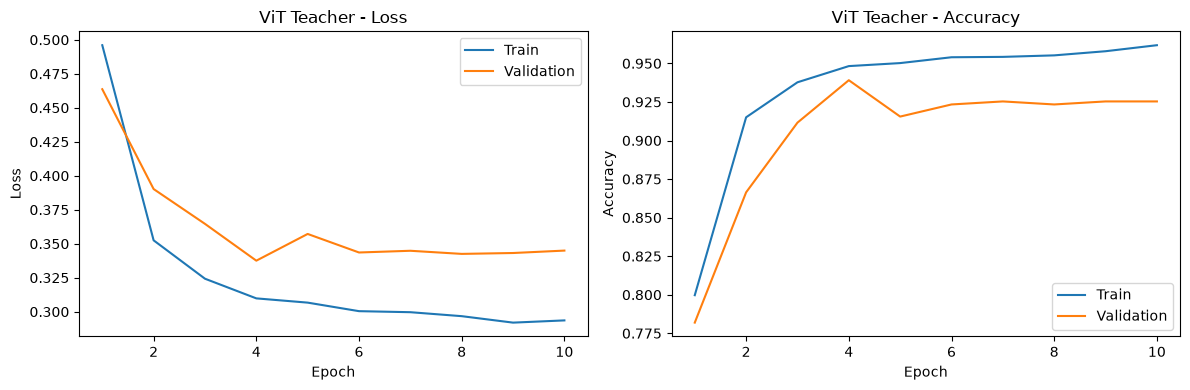

In [56]:
plot_history(
    vit_history,
    "ViT Teacher"
)

Load best ViT and Test


ViT Teacher
              precision    recall  f1-score   support

 Non_Uniform     0.5839    0.9560    0.7250        91
     Uniform     0.9375    0.4918    0.6452       122

    accuracy                         0.6901       213
   macro avg     0.7607    0.7239    0.6851       213
weighted avg     0.7864    0.6901    0.6793       213



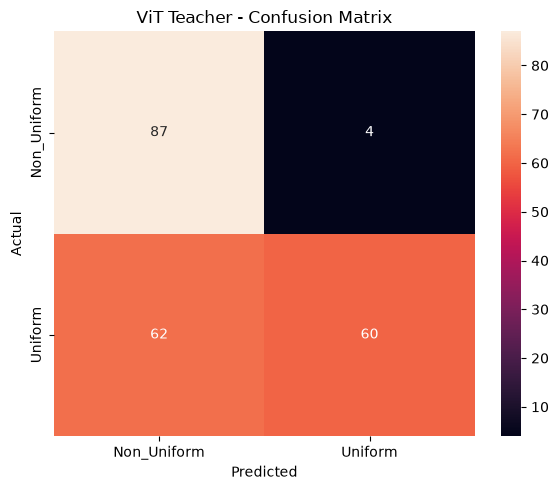

In [57]:
vit.load_state_dict(
    torch.load(
        "vit_best.pt",
        map_location=DEVICE
    )
)

y_true_vit, y_pred_vit = evaluate_test(
    vit,
    test_loader,
    "ViT Teacher"
)

**MOBILENETV3 BASELINE**

Create MobileNet

In [58]:
mobilenet = timm.create_model(
    "mobilenetv3_large_100",
    pretrained=True,
    num_classes=NUM_CLASSES
)

mobilenet = mobilenet.to(DEVICE)

mobilenet_params = sum(
    p.numel()
    for p in mobilenet.parameters()
)

print(
    f"MobileNetV3 parameters: "
    f"{mobilenet_params:,}"
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

MobileNetV3 parameters: 4,204,594


Train MobileNet

In [59]:
mobilenet_history = train_model(
    model=mobilenet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_MOBILENET,
    learning_rate=LR_MOBILENET,
    save_path="mobilenet_best.pt",
    model_name="MobileNetV3 Baseline"
)


Training: MobileNetV3 Baseline
Epoch [1/5] | Train Loss: 2.2054 | Train Acc: 0.5115 | Val Loss: 2.1441 | Val Acc: 0.4460 | Time: 15.9s
  -> Saved best model (val_loss=2.1441)
Epoch [2/5] | Train Loss: 2.1621 | Train Acc: 0.5129 | Val Loss: 2.2861 | Val Acc: 0.4420 | Time: 15.9s
Epoch [3/5] | Train Loss: 2.1755 | Train Acc: 0.5075 | Val Loss: 2.3823 | Val Acc: 0.4381 | Time: 16.0s
Epoch [4/5] | Train Loss: 2.1733 | Train Acc: 0.5129 | Val Loss: 2.3706 | Val Acc: 0.4263 | Time: 16.3s
Epoch [5/5] | Train Loss: 2.1566 | Train Acc: 0.5157 | Val Loss: 1.9208 | Val Acc: 0.5049 | Time: 16.3s
  -> Saved best model (val_loss=1.9208)

Best validation loss: 1.9208


Plot MobileNet

In [ ]:
plot_history(
    mobilenet_history,
    "MobileNetV3 Baseline"
)

Test MobileNet

In [ ]:
mobilenet.load_state_dict(
    torch.load(
        "mobilenet_best.pt",
        map_location=DEVICE
    )
)

y_true_mobile, y_pred_mobile = evaluate_test(
    mobilenet,
    test_loader,
    "MobileNetV3 Baseline"
)

**KNOWLEDGE DISTILLATION**

Freeze Teacher (ViT)

In [ ]:
teacher = vit

teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

Create Student (MobileNetV3)

In [ ]:
student = timm.create_model(
    "mobilenetv3_large_100",
    pretrained=True,
    num_classes=NUM_CLASSES
)

student = student.to(DEVICE)

student_params = sum(
    p.numel()
    for p in student.parameters()
)

print(
    f"Student parameters: "
    f"{student_params:,}"
)

Knowledge Distillation Loss

In [ ]:
def distillation_loss(
    student_logits,
    teacher_logits,
    labels,
    temperature=4.0,
    alpha=0.5
):

    # Hard-label loss
    hard_loss = F.cross_entropy(
        student_logits,
        labels
    )

    # Soft-label loss
    student_soft = F.log_softmax(
        student_logits / temperature,
        dim=1
    )

    teacher_soft = F.softmax(
        teacher_logits / temperature,
        dim=1
    )

    soft_loss = F.kl_div(
        student_soft,
        teacher_soft,
        reduction="batchmean"
    )

    soft_loss = (
        soft_loss *
        temperature ** 2
    )

    total_loss = (
        alpha * hard_loss
        +
        (1 - alpha) * soft_loss
    )

    return total_loss

KD Training Loop

In [ ]:
def train_kd(
    teacher,
    student,
    train_loader,
    val_loader,
    epochs,
    learning_rate,
    temperature,
    alpha,
    save_path
):

    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    best_val_acc = 0.0

    history = []


    print()
    print("=" * 70)
    print("Training MobileNetV3 with Knowledge Distillation")
    print("=" * 70)

    for epoch in range(epochs):

        start_time = time.time()

        student.train()
        teacher.eval()

        running_loss = 0.0
        correct = 0
        total = 0


        for images, labels in train_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad()


            # -------------------------
            # Teacher
            # -------------------------

            with torch.no_grad():

                teacher_logits = teacher(
                    images
                )


            # -------------------------
            # Student
            # -------------------------

            student_logits = student(
                images
            )


            # -------------------------
            # KD Loss
            # -------------------------

            loss = distillation_loss(
                student_logits,
                teacher_logits,
                labels,
                temperature=temperature,
                alpha=alpha
            )


            loss.backward()

            optimizer.step()


            running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = student_logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


        scheduler.step()


        train_loss = (
            running_loss / total
        )

        train_acc = (
            correct / total
        )


        # -------------------------
        # Validation
        # -------------------------

        val_loss, val_acc = evaluate(
            student,
            val_loader,
            nn.CrossEntropyLoss()
        )


        epoch_time = (
            time.time() - start_time
        )


        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })


        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| KD Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| Time: {epoch_time:.1f}s"
        )


        if val_acc > best_val_acc:

            best_val_acc = val_acc

            torch.save(
                student.state_dict(),
                save_path
            )

            print(
                f"  -> Saved best KD model "
                f"(val_acc={val_acc:.4f})"
            )


    print()
    print(
        f"Best KD validation accuracy: "
        f"{best_val_acc:.4f}"
    )


    return pd.DataFrame(history)

Train KD

In [ ]:
kd_history = train_kd(
    teacher=teacher,
    student=student,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_KD,
    learning_rate=LR_KD,
    temperature=KD_TEMPERATURE,
    alpha=KD_ALPHA,
    save_path="mobilenet_kd_best.pt"
)

Plot KD

In [ ]:
plot_history(
    kd_history,
    "MobileNetV3 Knowledge Distillation"
)

Test KD Student

In [ ]:
student.load_state_dict(
    torch.load(
        "mobilenet_kd_best.pt",
        map_location=DEVICE
    )
)

y_true_kd, y_pred_kd = evaluate_test(
    student,
    test_loader,
    "MobileNetV3 + Knowledge Distillation"
)

**COMPARE**

Metrics

In [ ]:
def get_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="weighted"
        )
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

Overall Comparison

In [ ]:
results = pd.DataFrame([

    {
        "Model": "ViT Teacher",
        **get_metrics(
            y_true_vit,
            y_pred_vit
        ),
        "Parameters": vit_params
    },

    {
        "Model": "MobileNetV3 Baseline",
        **get_metrics(
            y_true_mobile,
            y_pred_mobile
        ),
        "Parameters": mobilenet_params
    },

    {
        "Model": "MobileNetV3 + KD",
        **get_metrics(
            y_true_kd,
            y_pred_kd
        ),
        "Parameters": student_params
    }

])


results

Per-class Metrics

In [ ]:
def per_class_metrics(
    y_true,
    y_pred,
    model_name
):

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred
        )
    )

    rows = []

    for i, class_name in enumerate(CLASS_NAMES):

        rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": precision[i],
            "Recall": recall[i],
            "F1": f1[i],
            "Support": support[i]
        })

    return rows

In [ ]:
all_class_metrics = []

all_class_metrics += per_class_metrics(
    y_true_vit,
    y_pred_vit,
    "ViT Teacher"
)

all_class_metrics += per_class_metrics(
    y_true_mobile,
    y_pred_mobile,
    "MobileNetV3 Baseline"
)

all_class_metrics += per_class_metrics(
    y_true_kd,
    y_pred_kd,
    "MobileNetV3 + KD"
)


class_results = pd.DataFrame(
    all_class_metrics
)

class_results

Save all results

In [ ]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

class_results.to_csv(
    "per_class_metrics.csv",
    index=False
)

vit_history.to_csv(
    "vit_training_history.csv",
    index=False
)

mobilenet_history.to_csv(
    "mobilenet_training_history.csv",
    index=False
)

kd_history.to_csv(
    "kd_training_history.csv",
    index=False
)

print("Results saved!")